# ICNN vs NPF-ICNN adversary diagnostic

This notebook compares the old stable input ICNN and the new NPF/LastQuad ICNN on the same CIFAR-10 samples, classifier, DRO inner objective, BB+Armijo settings, and PGD reference attack.

In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd()
if repo_root.name == "pretrained_input_icnn":
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from pretrained_input_icnn.icnn_vs_npficnn_diagnostic import (
    architecture_dataframe,
    assert_shared_protocol,
    assert_shared_hidden_sizes,
    DiagnosticConfig,
    history_dataframe,
    plot_comparison_grid,
    protocol_dataframe,
    run_icnn_vs_npficnn_diagnostic,
    samples_dataframe,
    save_diagnostic_tables,
    set_shared_hidden_sizes,
    summarize_final_step,
)


/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Run-local mirrored setup

`DiagnosticConfig.from_run_local_env()` starts from the same defaults as `run_local_npf_lastquad.sh`. The small overrides below make the notebook interactive; remove them for the full local-launcher batch.

In [2]:
cfg = DiagnosticConfig.from_run_local_env()

# Interactive overrides. Delete or increase these for exact launcher scale.
cfg.batch_size = 64
cfg.max_samples = 100
cfg.num_workers = 0
cfg.num_visual_samples = 8
cfg.batch_index = 0
cfg.augment_train = False  # set True to include train-time crop/flip augmentation
cfg.npf_lastquad_identity_init = False 

# Keep all compared ICNN adversaries the same size and notebook-manageable.
shared_hidden = (512, 512, 256)
set_shared_hidden_sizes(cfg, shared_hidden)

# Keep the launcher's objective defaults visible here.
cfg.omega_steps = 20
cfg.penalty_lambda = 0.0976
cfg.transport_cost = "pixel_l2_squared"
cfg.use_margin_loss = False
cfg.attack_clean_correct_only = True

cfg


DiagnosticConfig(data_dir='/mloscratch/homes/aabdolla/LAT/data', pretrained_path='/mloscratch/homes/aabdolla/LAT/ResNet_checkpoints/R2.pth', pretrained_strict=False, device='auto', seed=1, split='train', batch_index=0, batch_size=64, max_samples=100, num_workers=0, augment_train=False, omega_steps=20, penalty_lambda=0.0976, transport_cost='pixel_l2_squared', use_margin_loss=False, attack_clean_correct_only=True, project_to_input_ball=False, bb_alpha0=0.0005, bb_alpha_min=1e-06, bb_alpha_max=1.0, bb_ls_c=0.1, bb_ls_shrink=0.5, bb_ls_max_steps=10, parametric_bb_max_grad_norm=1.0, legacy_icnn_hidden=(512, 512, 256), legacy_icnn_activation='softplus', legacy_icnn_strong_convexity=1.0, legacy_icnn_init='principled', npf_lastquad_hidden=(512, 512, 256), npf_lastquad_activation='softplus', npf_lastquad_elu_alpha=1.0, npf_lastquad_softplus_beta=20.0, npf_lastquad_output_rank=2, npf_lastquad_strong_convexity=1.0, npf_lastquad_identity_init=False, npf_lastquad_init_eps=0.01, npf_lastquad_pos_wei

## One isolated adversary comparison

Both adversaries see the same clean batch and frozen classifier. Step 0 is the initial transport before any BB+Armijo update.

In [3]:
result = run_icnn_vs_npficnn_diagnostic(
    cfg,
    variants=("legacy_icnn", "npf_lastquad"),
    verbose=True,
)


[diagnostic] device=cuda variants=('legacy_icnn', 'npf_lastquad')
[diagnostic] loading classifier: /mloscratch/homes/aabdolla/LAT/ResNet_checkpoints/R2.pth
[Pretrained] Loaded PreActResNet18 weights from: /mloscratch/homes/aabdolla/LAT/ResNet_checkpoints/R2.pth
[diagnostic] loading CIFAR-10 train batch 0
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
[diagnostic] PGD eps=1.44725, rho=0.05, C_p=28.9451
[diagnostic] clean_acc=1.000 attacked=64/64
[diagnostic] legacy_icnn: BB+Armijo omega ascent
[diagnostic] npf_lastquad: BB+Armijo omega ascent


In [4]:
assert_shared_protocol(result)
assert_shared_hidden_sizes(result)
display(architecture_dataframe(result))
display(protocol_dataframe(result))

hist = history_dataframe(result)
display(summarize_final_step(result))

cols = [
    "variant",
    "step",
    "objective_raw_masked",
    "primary_raw_masked",
    "cost_raw_masked",
    "raw_normalized_mse_masked",
    "raw_pixel_l2_squared_masked",
    "applied_acc",
    "applied_avg_l2",
    "applied_max_l2",
    "applied_avg_normalized_mse",
    "applied_avg_pixel_l2_squared",
    "cos_to_pgd_mean",
    "grad_norm",
    "bb_alpha",
]
display(hist[[c for c in cols if c in hist.columns]])


,variant,hidden_sizes,hidden_depth,hidden_max_width,num_parameters,trainable_parameters,outer_quadratic_trainable
0,legacy_icnn,"(512, 512, 256)",3,512,4330754,4330754,None
1,npf_lastquad,"(512, 512, 256)",3,512,4345346,4339201,False


,variant,omega_steps,lambda_param,transport_cost,use_margin_loss,attack_clean_correct_only,project_to_input_ball,bb_alpha0,bb_alpha_min,bb_alpha_max,...,bb_ls_shrink,bb_ls_max_steps,parametric_bb_max_grad_norm,input_pgd_geometry,input_pgd_loss,inp_p,inp_eps_config,effective_pgd_eps,wrm_normalized_radius,wrm_cp
0,legacy_icnn,20,0.0976,pixel_l2_squared,False,True,False,0.0005,0.000001,1.0,...,0.5,10,1.0,pixel_l2_squared,ce,2,0.05,1.447254,0.05,28.945077
1,npf_lastquad,20,0.0976,pixel_l2_squared,False,True,False,0.0005,0.000001,1.0,...,0.5,10,1.0,pixel_l2_squared,ce,2,0.05,1.447254,0.05,28.945077


,variant,step,objective_raw_masked,primary_raw_masked,cost_raw_masked,raw_normalized_mse_masked,raw_pixel_l2_squared_masked,applied_acc,applied_avg_l2,applied_max_l2,applied_avg_normalized_mse,applied_avg_pixel_l2_squared,cos_to_pgd_mean,grad_norm,bb_alpha
0,legacy_icnn,20,0.064160,0.072155,0.081924,0.000661,0.081924,1.0,0.286145,0.289891,0.000661,0.081924,0.005562,0.027496,0.000001
1,npf_lastquad,20,-0.195209,0.070329,2.720675,0.021949,2.720675,1.0,1.609209,2.427735,0.021949,2.720675,-0.027525,0.049382,0.081538


,variant,step,objective_raw_masked,primary_raw_masked,cost_raw_masked,raw_normalized_mse_masked,raw_pixel_l2_squared_masked,applied_acc,applied_avg_l2,applied_max_l2,applied_avg_normalized_mse,applied_avg_pixel_l2_squared,cos_to_pgd_mean,grad_norm,bb_alpha
0,legacy_icnn,0,0.064158,0.072154,0.081924,0.000661,0.081924,1.0,0.286145,0.289891,0.000661,0.081924,0.005562,NaN,NaN
1,legacy_icnn,1,0.064159,0.072155,0.081924,0.000661,0.081924,1.0,0.286145,0.289891,0.000661,0.081924,0.005562,0.027494,0.000008
2,legacy_icnn,2,0.064159,0.072155,0.081924,0.000661,0.081924,1.0,0.286145,0.289891,0.000661,0.081924,0.005562,0.027500,0.000001
3,legacy_icnn,3,0.064160,0.072155,0.081924,0.000661,0.081924,1.0,0.286145,0.289891,0.000661,0.081924,0.005562,0.027497,0.000001
4,legacy_icnn,4,0.064160,0.072155,0.081924,0.000661,0.081924,1.0,0.286145,0.289891,0.000661,0.081924,0.005562,0.027496,0.000001
5,legacy_icnn,5,0.064160,0.072155,0.081924,0.000661,0.081924,1.0,0.286145,0.289891,0.000661,0.081924,0.005562,0.027496,0.000001
6,legacy_icnn,6,0.064160,0.072155,0.081924,0.000661,0.081924,1.0,0.286145,0.289891,0.000661,0.081924,0.005562,0.027496,0.000001
7,legacy_icnn,7,0.064160,0.072155,0.081924,0.000661,0.081924,1.0,0.286145,0.289891,0.000661,0.081924,0.005562,0.027496,0.000001
8,legacy_icnn,8,0.064160,0.072155,0.081924,0.000661,0.081924,1.0,0.286145,0.289891,0.000661,0.081924,0.005562,0.027496,0.000001
9,legacy_icnn,9,0.064160,0.072155,0.081924,0.000661,0.081924,1.0,0.286145,0.289891,0.000661,0.081924,0.005562,0.027496,0.000001


## Same samples and perturbations

The grid shows clean inputs, PGD reference attacks, learned ICNN attacks, and matched perturbation maps. Perturbation colors are scaled globally inside the plotted subset.

PosixPath('/mloscratch/homes/aabdolla/LAT/pretrained_input_icnn/debug_outputs/icnn_vs_npficnn_grid.png')

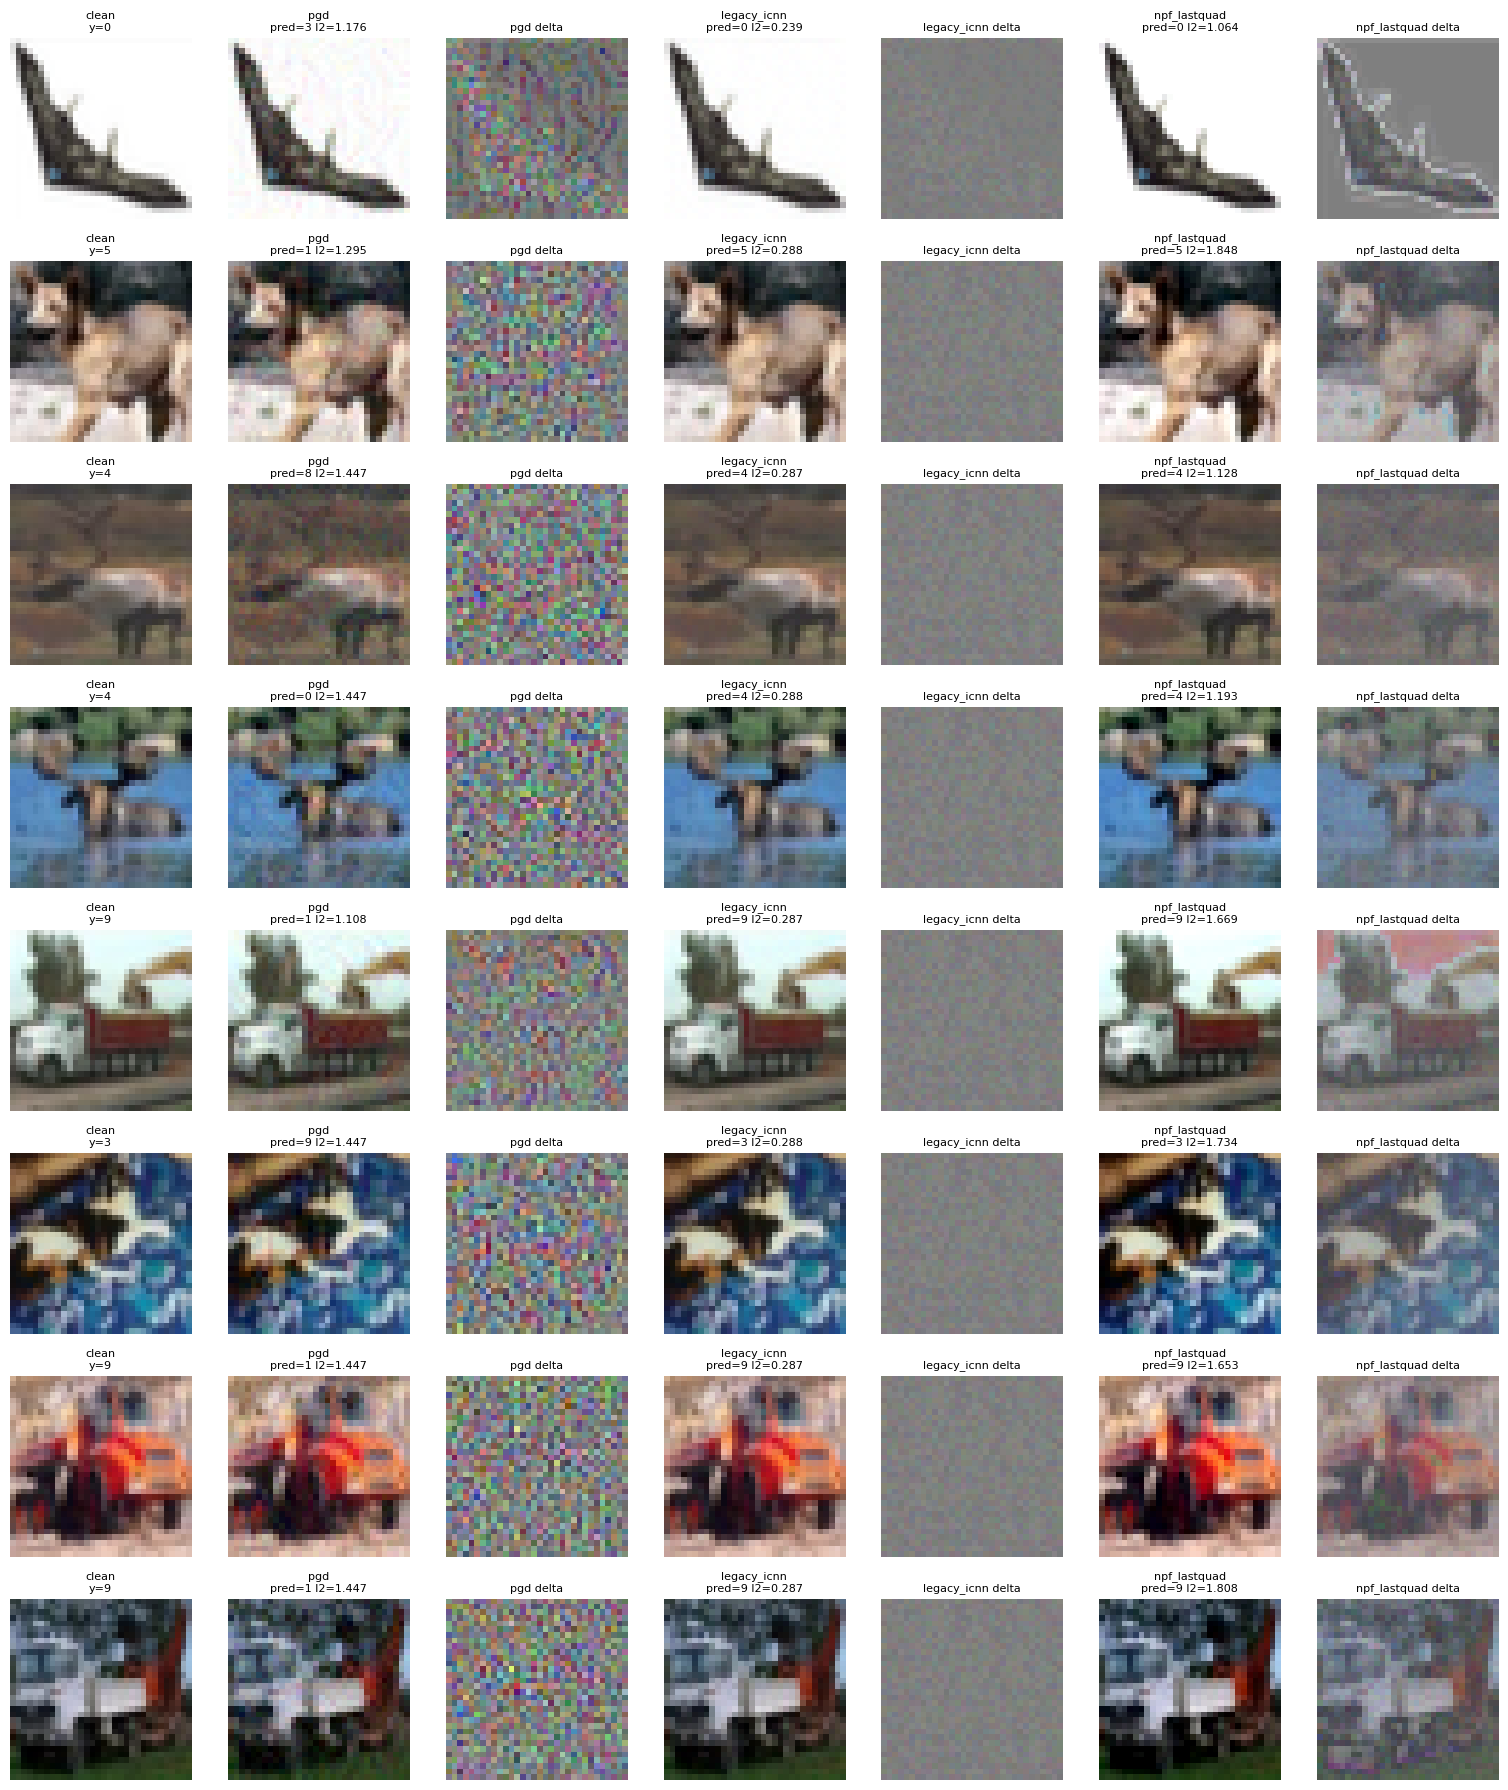

In [5]:
grid_path = Path(cfg.output_dir) / "icnn_vs_npficnn_grid.png"
fig = plot_comparison_grid(result, n=cfg.num_visual_samples, save_path=str(grid_path))
grid_path


In [6]:
samples = samples_dataframe(result)
display(
    samples[
        [
            "sample",
            "variant",
            "label",
            "pred",
            "correct",
            "pixel_l2",
            "pixel_linf",
            "normalized_mse",
            "pixel_l2_squared",
            "cos_to_pgd",
            "attacked",
        ]
    ].sort_values(["sample", "variant"])
)


,sample,variant,label,pred,correct,pixel_l2,pixel_linf,normalized_mse,pixel_l2_squared,cos_to_pgd,attacked
0,0,clean,0,0,True,0.000000,0.000000,0.000000,0.000000,NaN,True
64,0,legacy_icnn,0,0,True,0.238860,0.012765,0.000460,0.057054,0.162559,True
128,0,npf_lastquad,0,0,True,1.064110,0.068896,0.009134,1.132331,-0.039623,True
192,0,pgd_reference,0,3,False,1.175750,0.084826,0.011154,1.382387,1.000000,True
1,1,clean,5,5,True,0.000000,0.000000,0.000000,0.000000,NaN,True
...,...,...,...,...,...,...,...,...,...,...,...
254,62,pgd_reference,0,6,False,1.447175,0.095788,0.016894,2.094316,1.000000,True
63,63,clean,9,9,True,0.000000,0.000000,0.000000,0.000000,NaN,True
127,63,legacy_icnn,9,9,True,0.287836,0.013609,0.000668,0.082849,0.006195,True
191,63,npf_lastquad,9,9,True,1.922011,0.071837,0.029873,3.694127,-0.018776,True


In [7]:
paths = save_diagnostic_tables(result)
paths


{'history': PosixPath('/mloscratch/homes/aabdolla/LAT/pretrained_input_icnn/debug_outputs/icnn_vs_npficnn_history.csv'),
 'samples': PosixPath('/mloscratch/homes/aabdolla/LAT/pretrained_input_icnn/debug_outputs/icnn_vs_npficnn_samples.csv')}

## Cost/loss scaling ablation

Run this cell to check whether the failure is mainly from the newer run-local scaling (`pixel_l2_squared`, lambda `0.0976`, CE) versus the old stable scaling (`normalized_mse`, lambda `30`, margin).

[diagnostic] device=cuda variants=('legacy_icnn', 'npf_lastquad')
[diagnostic] loading classifier: /mloscratch/homes/aabdolla/LAT/ResNet_checkpoints/R2.pth
[Pretrained] Loaded PreActResNet18 weights from: /mloscratch/homes/aabdolla/LAT/ResNet_checkpoints/R2.pth
[diagnostic] loading CIFAR-10 train batch 0
Files already downloaded and verified
Files already downloaded and verified
[diagnostic] PGD eps=0.5
[diagnostic] clean_acc=1.000 attacked=64/64
[diagnostic] legacy_icnn: BB+Armijo omega ascent
[diagnostic] npf_lastquad: BB+Armijo omega ascent


,variant,hidden_sizes,hidden_depth,hidden_max_width,num_parameters,trainable_parameters,outer_quadratic_trainable
0,legacy_icnn,"(512, 512, 256)",3,512,4330754,4330754,None
1,npf_lastquad,"(512, 512, 256)",3,512,4345346,4339201,False


,variant,omega_steps,lambda_param,transport_cost,use_margin_loss,attack_clean_correct_only,project_to_input_ball,bb_alpha0,bb_alpha_min,bb_alpha_max,...,bb_ls_shrink,bb_ls_max_steps,parametric_bb_max_grad_norm,input_pgd_geometry,input_pgd_loss,inp_p,inp_eps_config,effective_pgd_eps,wrm_normalized_radius,wrm_cp
0,legacy_icnn,10,30.0,normalized_mse,True,True,False,0.0005,0.000001,1.0,...,0.5,10,1.0,pixel_l2_squared,margin,2,0.5,0.5,None,None
1,npf_lastquad,10,30.0,normalized_mse,True,True,False,0.0005,0.000001,1.0,...,0.5,10,1.0,pixel_l2_squared,margin,2,0.5,0.5,None,None


,variant,step,objective_raw_masked,primary_raw_masked,cost_raw_masked,raw_normalized_mse_masked,raw_pixel_l2_squared_masked,applied_acc,applied_avg_l2,applied_max_l2,applied_avg_normalized_mse,applied_avg_pixel_l2_squared,cos_to_pgd_mean,grad_norm,bb_alpha
0,legacy_icnn,10,-2.146345,-2.102556,0.001460,0.001460,0.180889,0.984375,0.425190,0.431009,0.001460,0.180889,0.025984,0.401214,1.000000
1,npf_lastquad,10,-1.639782,-1.550565,0.002974,0.002974,0.368571,0.921875,0.526933,1.428391,0.002974,0.368571,0.021329,1.000000,0.240192


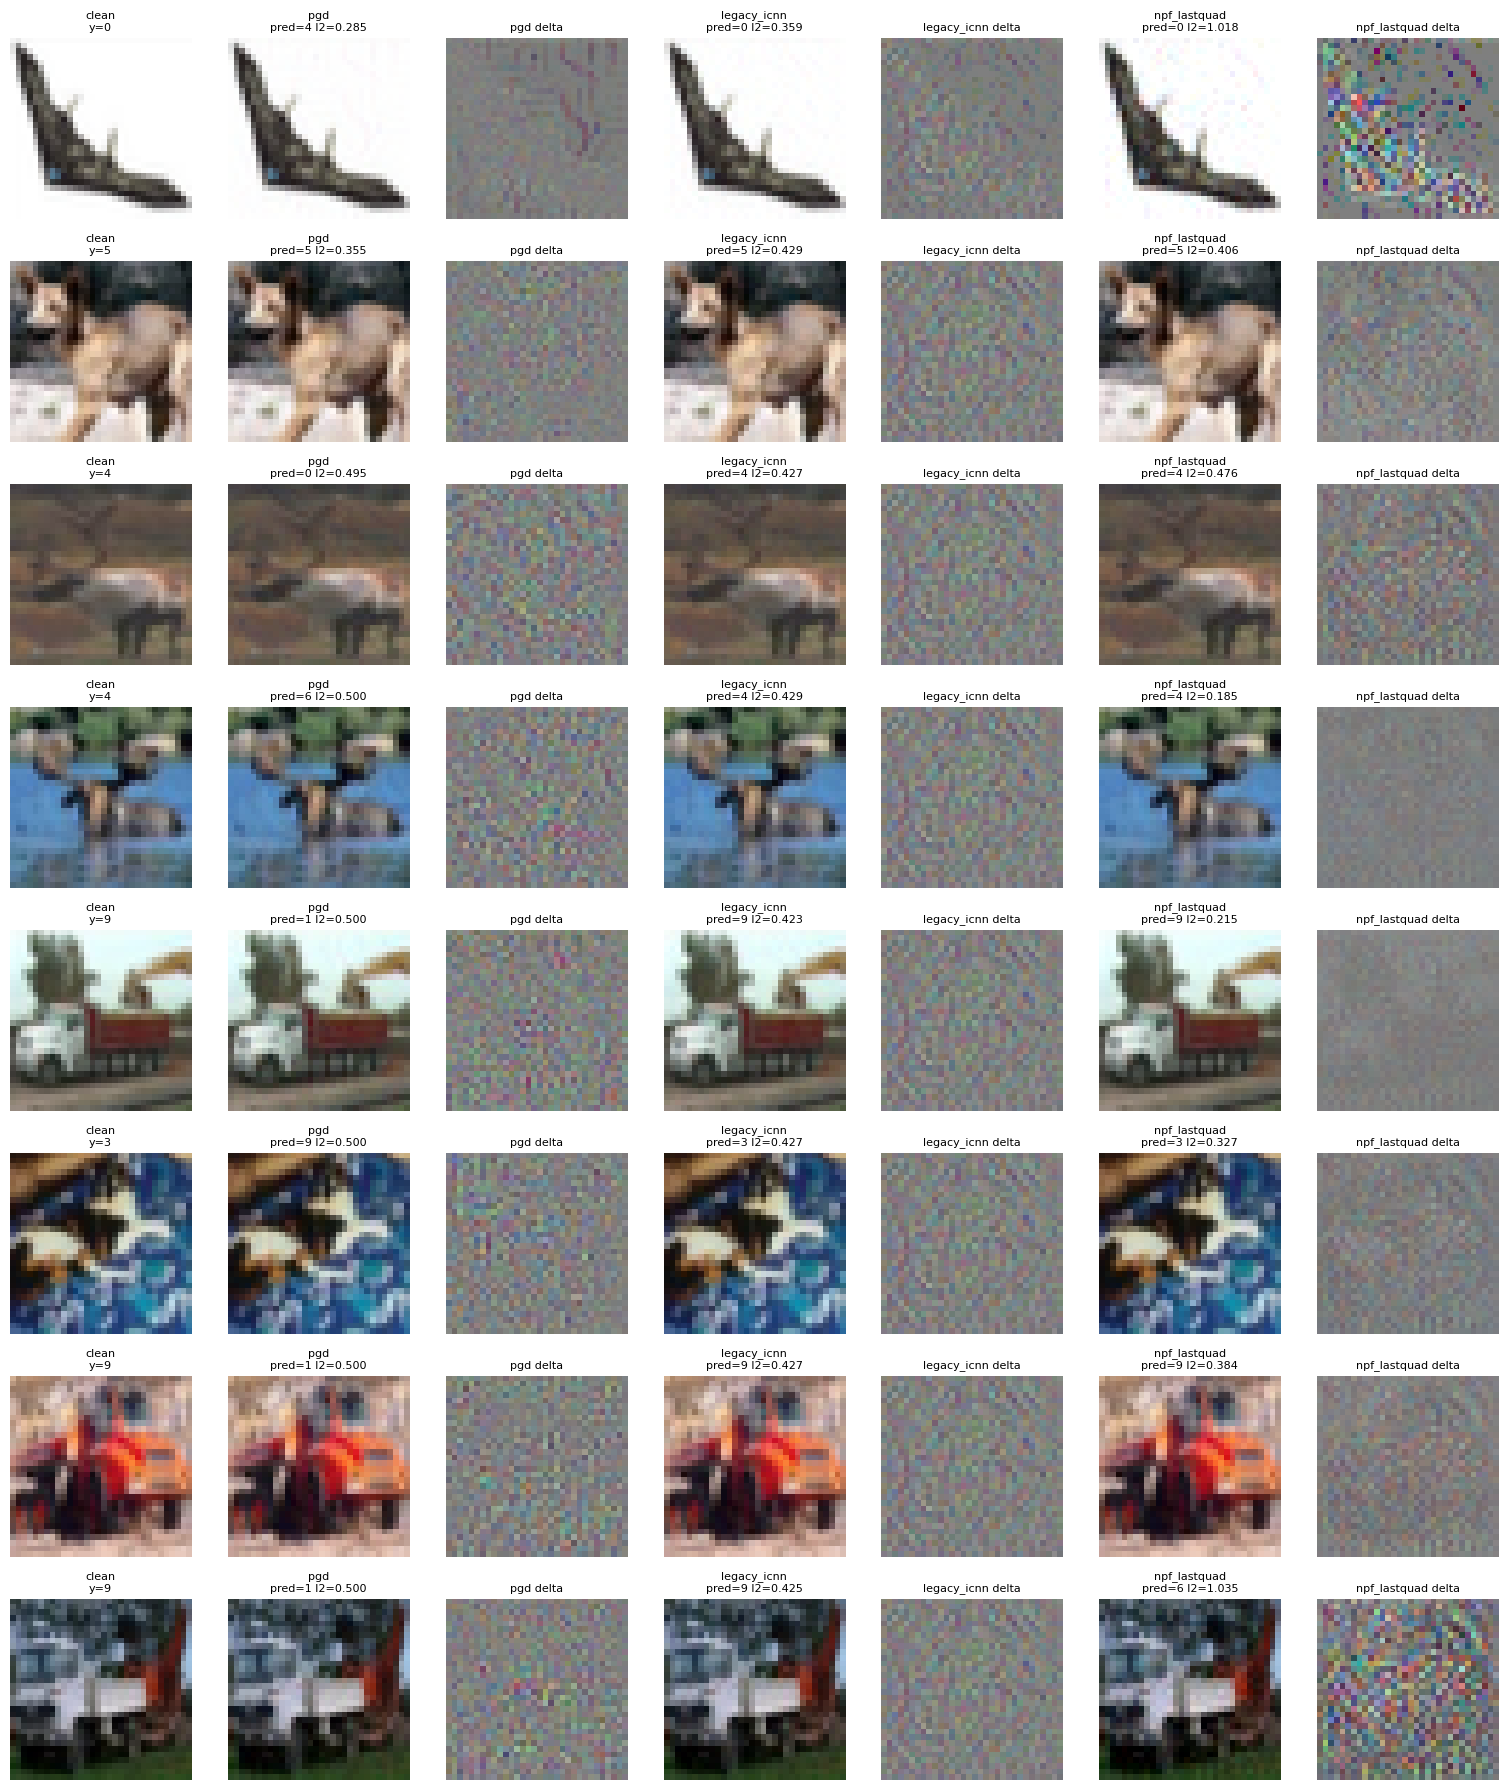

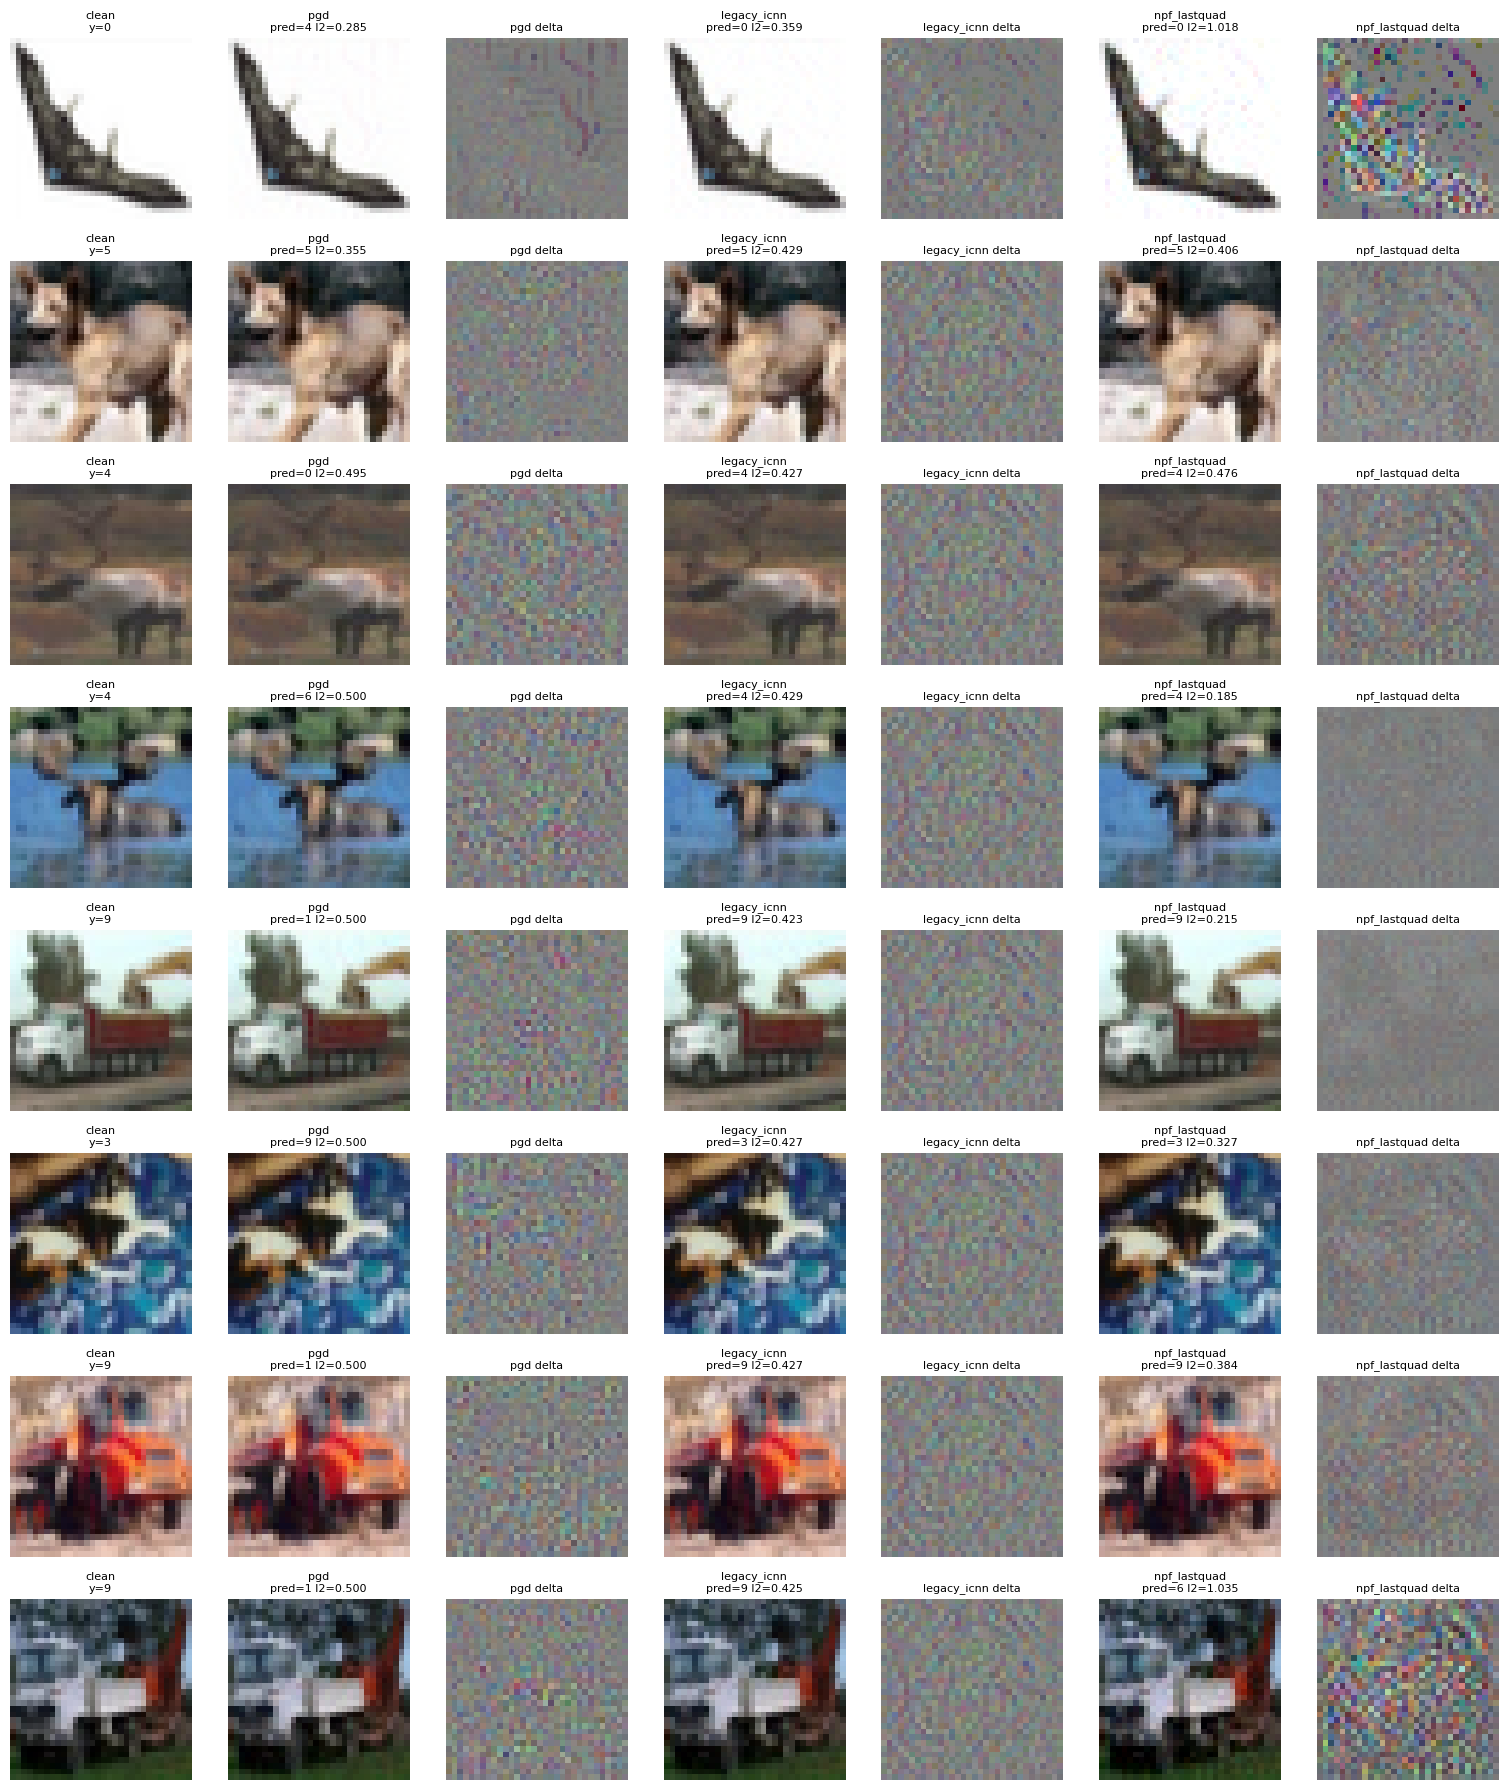

In [8]:
legacy_cfg = DiagnosticConfig.legacy_stable_parity()
legacy_cfg.batch_size = cfg.batch_size
legacy_cfg.max_samples = cfg.max_samples
legacy_cfg.num_workers = cfg.num_workers
legacy_cfg.num_visual_samples = cfg.num_visual_samples
legacy_cfg.batch_index = cfg.batch_index
legacy_cfg.augment_train = cfg.augment_train
set_shared_hidden_sizes(legacy_cfg, shared_hidden)
legacy_result = run_icnn_vs_npficnn_diagnostic(
    legacy_cfg,
    variants=("legacy_icnn", "npf_lastquad"),
    verbose=True,
)
assert_shared_protocol(legacy_result)
assert_shared_hidden_sizes(legacy_result)
display(architecture_dataframe(legacy_result))
display(protocol_dataframe(legacy_result))
display(summarize_final_step(legacy_result))
plot_comparison_grid(
    legacy_result,
    n=legacy_cfg.num_visual_samples,
    save_path=str(Path(legacy_cfg.output_dir) / "icnn_vs_npficnn_legacy_scaling_grid.png"),
)


## Optional full NPF ablation

Use this to check whether the LastQuad restriction is the problem rather than the NPF parameterization itself.

[diagnostic] device=cuda variants=('legacy_icnn', 'npf_lastquad', 'npf')
[diagnostic] loading classifier: /mloscratch/homes/aabdolla/LAT/ResNet_checkpoints/R2.pth
[Pretrained] Loaded PreActResNet18 weights from: /mloscratch/homes/aabdolla/LAT/ResNet_checkpoints/R2.pth
[diagnostic] loading CIFAR-10 train batch 0
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
[diagnostic] PGD eps=1.44725, rho=0.05, C_p=28.9451
[diagnostic] clean_acc=1.000 attacked=64/64
[diagnostic] legacy_icnn: BB+Armijo omega ascent
[diagnostic] npf_lastquad: BB+Armijo omega ascent
[diagnostic] npf: BB+Armijo omega ascent


,variant,hidden_sizes,hidden_depth,hidden_max_width,num_parameters,trainable_parameters,outer_quadratic_trainable
0,legacy_icnn,"(512, 512, 256)",3,512,4330754,4330754,None
1,npf_lastquad,"(512, 512, 256)",3,512,4345346,4339201,False
2,npf,"(512, 512, 256)",3,512,16166402,16166402,True


,variant,omega_steps,lambda_param,transport_cost,use_margin_loss,attack_clean_correct_only,project_to_input_ball,bb_alpha0,bb_alpha_min,bb_alpha_max,...,bb_ls_shrink,bb_ls_max_steps,parametric_bb_max_grad_norm,input_pgd_geometry,input_pgd_loss,inp_p,inp_eps_config,effective_pgd_eps,wrm_normalized_radius,wrm_cp
0,legacy_icnn,20,0.0976,pixel_l2_squared,False,True,False,0.0005,0.000001,1.0,...,0.5,10,1.0,pixel_l2_squared,ce,2,0.05,1.447254,0.05,28.945077
1,npf_lastquad,20,0.0976,pixel_l2_squared,False,True,False,0.0005,0.000001,1.0,...,0.5,10,1.0,pixel_l2_squared,ce,2,0.05,1.447254,0.05,28.945077
2,npf,20,0.0976,pixel_l2_squared,False,True,False,0.0005,0.000001,1.0,...,0.5,10,1.0,pixel_l2_squared,ce,2,0.05,1.447254,0.05,28.945077


,variant,step,objective_raw_masked,primary_raw_masked,cost_raw_masked,raw_normalized_mse_masked,raw_pixel_l2_squared_masked,applied_acc,applied_avg_l2,applied_max_l2,applied_avg_normalized_mse,applied_avg_pixel_l2_squared,cos_to_pgd_mean,grad_norm,bb_alpha
0,legacy_icnn,20,0.064160,0.072155,0.081924,0.000661,0.081924,1.0,0.286145,0.289891,0.000661,0.081924,0.005562,0.027496,0.000001
1,npf_lastquad,20,-0.195209,0.070329,2.720675,0.021949,2.720675,1.0,1.609209,2.427735,0.021949,2.720675,-0.027525,0.049382,0.081538
2,npf,20,-0.181541,0.072176,2.599554,0.020972,2.599554,1.0,1.572992,2.363664,0.020972,2.599554,-0.027684,0.116426,0.107559


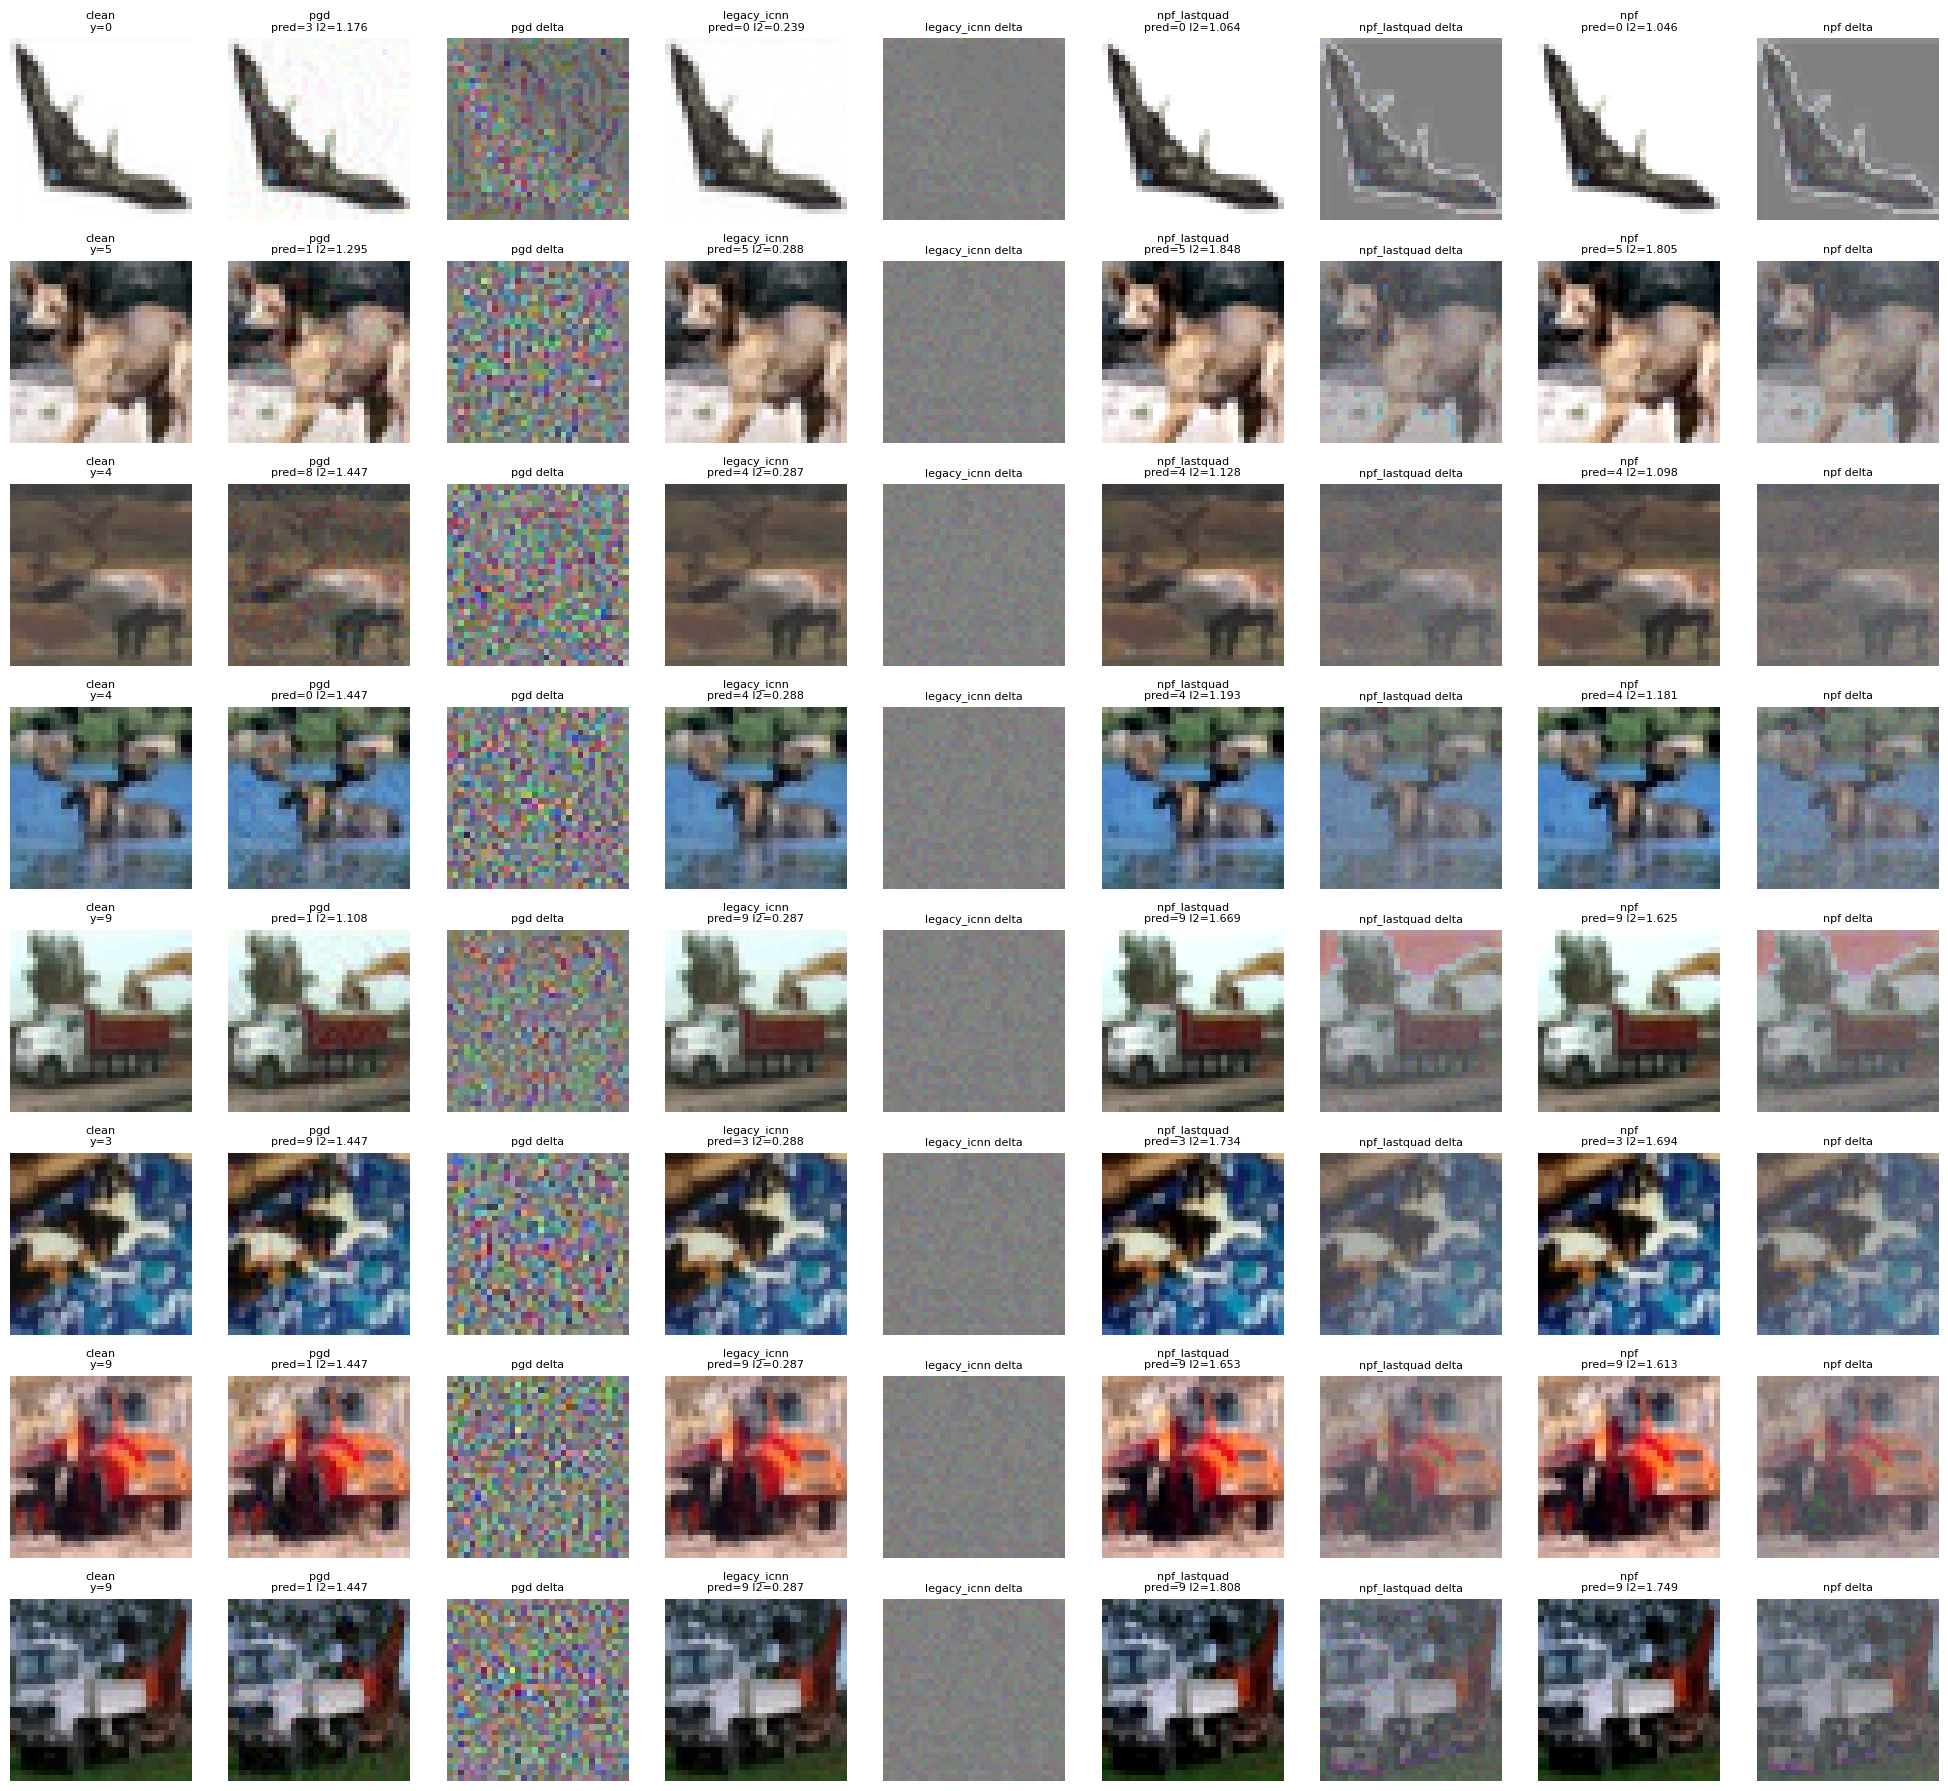

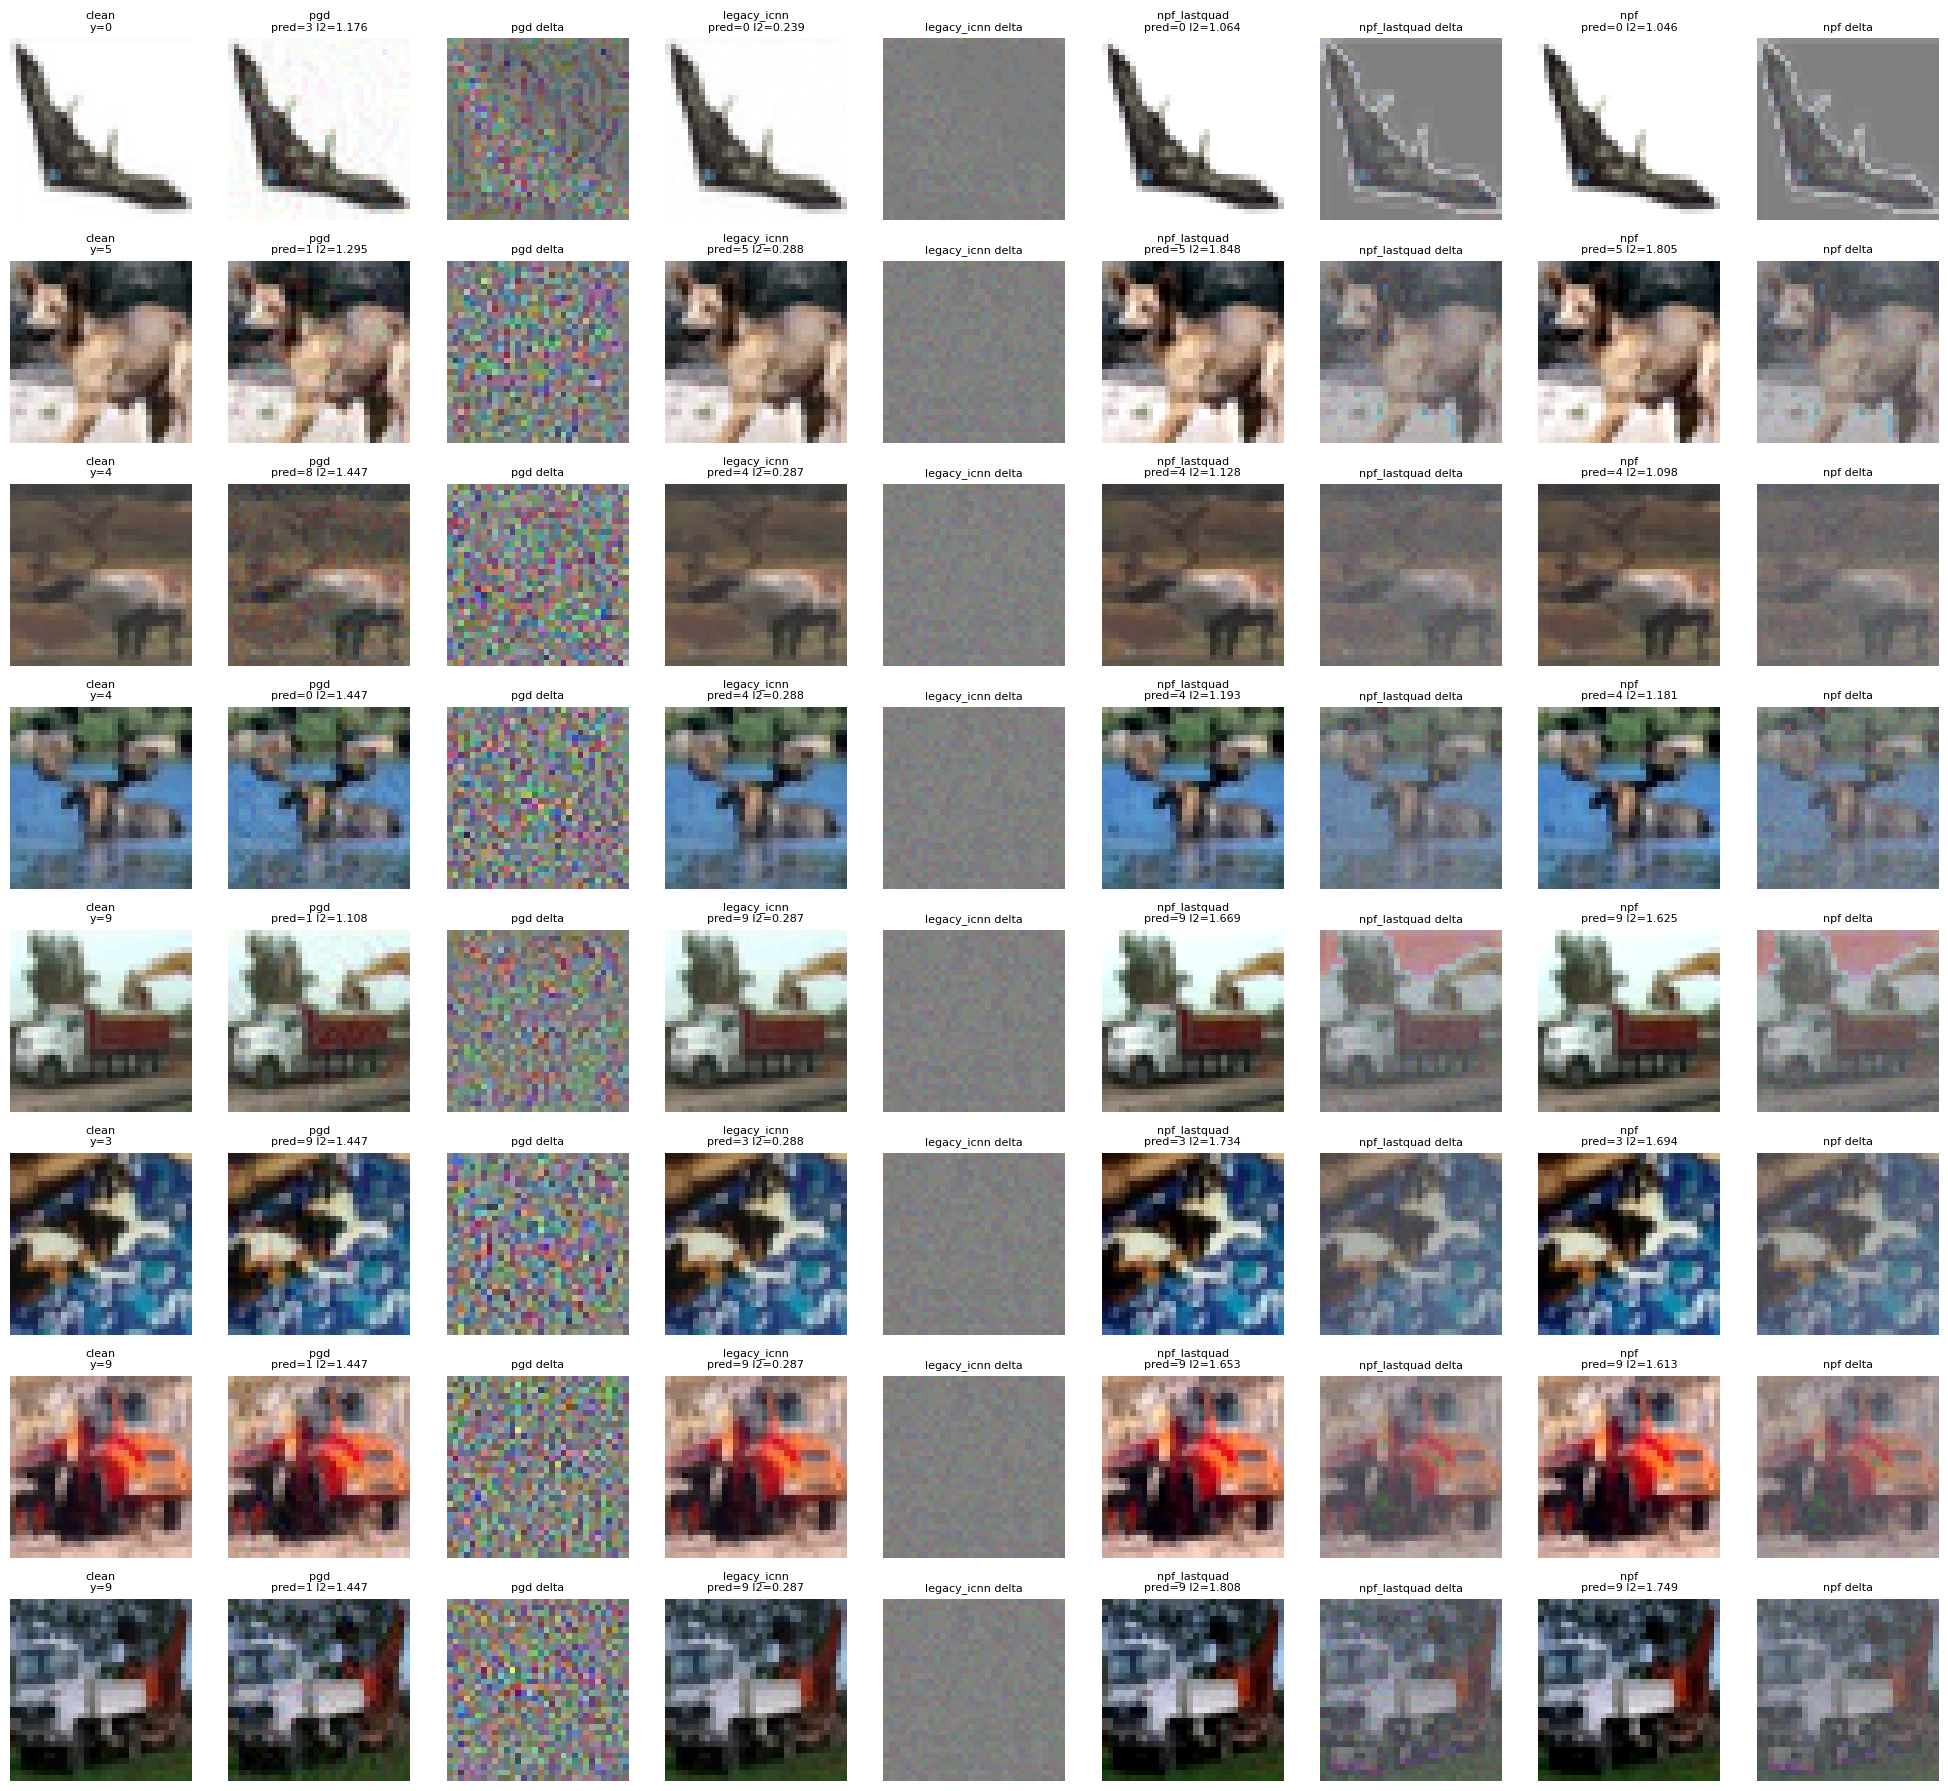

In [9]:
full_npf_result = run_icnn_vs_npficnn_diagnostic(
    cfg,
    variants=("legacy_icnn", "npf_lastquad", "npf"),
    verbose=True,
)
assert_shared_protocol(full_npf_result)
assert_shared_hidden_sizes(full_npf_result)
display(architecture_dataframe(full_npf_result))
display(protocol_dataframe(full_npf_result))
display(summarize_final_step(full_npf_result))
plot_comparison_grid(full_npf_result, n=cfg.num_visual_samples)


# Why LastQuad "fools" the model without being adversarial

The cells below answer the central puzzle visually: **the trained NPF-LastQuad transport misclassifies a large fraction of samples, yet training on it gives no PGD robustness.**

Setup: the launcher-default LastQuad adversary (hidden `1024 512 512 256 128 64`, `exp` rectifier, random principled init) is trained on ONE fixed clean-correct test batch with the main setting — **lambda=30 on the normalized-MSE cost**, margin loss, 200 persistent BB+Armijo steps (≈ 20 batches' worth of K=10), eval-mode classifier — then compared against pixel-L2 PGD at the eps=0.5 benchmark radius along four axes:

1. **Attack power at equal radius** — project T(x) into the eps=0.5 ball and re-classify.
2. **Sample-dependence** — how much of the perturbation energy lives in ONE shared direction (batch-mean; SVD spectrum of the 96×3072 delta matrix).
3. **Spatial structure** — radial FFT profile of the deltas.
4. **The images themselves.**

In [ ]:
import json
import numpy as np
import torch
import matplotlib.pyplot as plt

from pretrained_input_icnn.data import get_cifar10_loaders
from pretrained_input_icnn.models.classifier import load_pretrained_classifier
from pretrained_input_icnn.models.npf import NPFInputConvexPotential, npf_T_omega
from pretrained_input_icnn.utils import (
    BBArmijoState, adversary_loss_per_sample, bb_armijo_step_params,
    clamped_normalized_copy, input_pgd_best_adversary, normalized_mse,
    set_requires_grad,
)
from pretrained_input_icnn.utils.transforms import (
    project_normalized_to_pixel_lp_ball, to_pixel,
)

torch.manual_seed(0)
DEV = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CLASSES = ("plane", "car", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck")
LAMBDA, EPS, K_TOTAL, BATCH = 30.0, 0.5, 200, 96   # main setting: lambda=30, normalized-MSE

classifier = load_pretrained_classifier(str(repo_root / "ResNet_checkpoints/R2.pth"), device=DEV)
classifier.eval(); set_requires_grad(classifier, False)

_, test_loader, _ = get_cifar10_loaders(
    batch_size=256, num_workers=0, data_root=str(repo_root / "data"),
    augment_train=False, pin_memory=DEV.type == "cuda", download=True, seed=0)
x_all, y_all = next(iter(test_loader))
x_all, y_all = x_all.to(DEV), y_all.to(DEV)
with torch.no_grad():
    keep = classifier(x_all).argmax(1) == y_all
x, y = x_all[keep][:BATCH].contiguous(), y_all[keep][:BATCH].contiguous()

psi = NPFInputConvexPotential(
    input_dim=3 * 32 * 32, hidden_sizes=[1024, 512, 512, 256, 128, 64],
    outer_rank=0, inner_rank=0, output_rank=2,
    quadratic_mode="last_layer_diagonal", trainable_outer_quadratic=False,
    activation="softplus", softplus_beta=20.0, init_eps=0.0,
    strong_convexity=1.0, pos_weights=True, positive_weight_rectifier="exp",
).to(DEV)
psi.enforce_trainable_constraints()

def omega_objective(create_graph):
    x_adv = clamped_normalized_copy(npf_T_omega(x, psi, create_graph=create_graph))
    per = adversary_loss_per_sample(classifier(x_adv), y, use_margin=True)
    obj = (per - LAMBDA * normalized_mse(x_adv, x)).mean()
    return torch.nan_to_num(obj, nan=-1e12, posinf=-1e12, neginf=-1e12)

st = BBArmijoState.create(alpha0=5e-4, alpha_min=1e-6, alpha_max=1.0, ls_c=0.1,
                          ls_shrink=0.5, ls_max_steps=10, reject_on_armijo_failure=True)
trace = []
for k in range(K_TOTAL):
    _, st, f_val, g_norm = bb_armijo_step_params(
        psi.parameters(), omega_objective, st, max_grad_norm=1.0)
    if k % 10 == 0 or k == K_TOTAL - 1:
        with torch.no_grad():
            x_t = clamped_normalized_copy(npf_T_omega(x, psi, create_graph=False))
            acc_t = (classifier(x_t).argmax(1) == y).float().mean().item()
            cost_t = normalized_mse(x_t, x).mean().item()
        trace.append(dict(step=k, obj=f_val, acc_T=acc_t, cost=cost_t, alpha=st.alpha_prev))
        print(f"step {k:3d} obj={f_val:8.3f} alpha={st.alpha_prev:.2e} "
              f"acc(T)={acc_t*100:5.1f}% cost={cost_t:.4f}")

In [ ]:
# References: final transport, its eps=0.5 projection, and the PGD benchmark attack.
with torch.no_grad():
    x_T = clamped_normalized_copy(npf_T_omega(x, psi, create_graph=False))
x_Tproj = project_normalized_to_pixel_lp_ball(x_T, x, eps=EPS, p=2)
x_pgd, _ = input_pgd_best_adversary(
    classifier, x.detach(), y, p=2, eps=EPS, steps=20, step_size=None,
    restarts=5, loss="margin", geometry="pixel_l2_squared")

with torch.no_grad():
    preds = {n: classifier(t).argmax(1)
             for n, t in [("clean", x), ("T", x_T), ("Tproj", x_Tproj), ("pgd", x_pgd)]}
accs = {k: (v == y).float().mean().item() for k, v in preds.items()}

d_T = (to_pixel(x_T) - to_pixel(x)).flatten(1)
d_P = (to_pixel(x_pgd) - to_pixel(x)).flatten(1)
l2_T, l2_P = d_T.norm(dim=1), d_P.norm(dim=1)
cos_TP = torch.nn.functional.cosine_similarity(d_T, d_P, dim=1)

def shared_energy(d):
    mu = d.mean(0, keepdim=True)
    mu = mu / mu.norm().clamp_min(1e-12)
    return (d @ mu.T).pow(2).squeeze(1) / d.pow(2).sum(1).clamp_min(1e-12)

shared_T, shared_P = shared_energy(d_T), shared_energy(d_P)
sv_T, sv_P = torch.linalg.svdvals(d_T.cpu()), torch.linalg.svdvals(d_P.cpu())
en_T = (sv_T**2 / (sv_T**2).sum()).cumsum(0)
en_P = (sv_P**2 / (sv_P**2).sum()).cumsum(0)

def radial_fft_profile(d_flat):
    d = d_flat.reshape(-1, 3, 32, 32).mean(1)
    spec = torch.fft.fftshift(torch.fft.fft2(d.cpu()), dim=(-2, -1)).abs().mean(0).numpy()
    yy, xx = np.mgrid[0:32, 0:32]
    r = np.sqrt((yy - 16) ** 2 + (xx - 16) ** 2).astype(int)
    prof = np.array([spec[r == k].mean() for k in range(16)])
    return prof / prof.sum()

prof_T, prof_P = radial_fft_profile(d_T), radial_fft_profile(d_P)

print(f"accuracy: clean {accs['clean']*100:.1f}% | T(x) {accs['T']*100:.1f}% | "
      f"T projected to eps=0.5: {accs['Tproj']*100:.1f}% | PGD eps=0.5: {accs['pgd']*100:.1f}%")
print(f"pixel L2: transport mean {l2_T.mean():.2f} (max {l2_T.max():.2f}) vs PGD {l2_P.mean():.2f}")
print(f"cos(delta_T, delta_PGD): mean {cos_TP.mean():.4f}  (3072-D random baseline ~ 0.014)")
print(f"energy in batch-mean direction: transport {shared_T.mean()*100:.1f}% vs PGD {shared_P.mean()*100:.1f}%")
print(f"SVD energy top-1: transport {en_T[0]*100:.1f}% vs PGD {en_P[0]*100:.1f}%  |  "
      f"top-5: {en_T[4]*100:.1f}% vs {en_P[4]*100:.1f}%")

In [ ]:
# Image grid: clean / T(x) / transport delta / T projected / PGD / PGD delta.
def _show(ax, img_norm, title, ok=None):
    ax.imshow(to_pixel(img_norm.unsqueeze(0))[0].clamp(0, 1).permute(1, 2, 0).cpu().numpy())
    ax.set_title(title, fontsize=7, color="black" if ok is None else ("green" if ok else "red"))
    ax.axis("off")

def _show_delta(ax, delta_pix, title):
    d = delta_pix.cpu()
    ax.imshow((0.5 + 0.5 * d / d.abs().max().clamp_min(1e-12)).permute(1, 2, 0).numpy())
    ax.set_title(title, fontsize=7); ax.axis("off")

n_show = 8
rows = ["clean", "T(x)", "delta T (amp)", "T proj eps=0.5", "PGD eps=0.5", "delta PGD (amp)"]
fig, axes = plt.subplots(len(rows), n_show, figsize=(1.6 * n_show, 1.7 * len(rows)))
for j in range(n_show):
    dT_img = (to_pixel(x_T[j:j+1]) - to_pixel(x[j:j+1]))[0]
    dP_img = (to_pixel(x_pgd[j:j+1]) - to_pixel(x[j:j+1]))[0]
    _show(axes[0, j], x[j], CLASSES[y[j]], True)
    _show(axes[1, j], x_T[j], f"{CLASSES[preds['T'][j]]} |d|={l2_T[j]:.2f}", bool(preds['T'][j] == y[j]))
    _show_delta(axes[2, j], dT_img, "low-freq / shared")
    _show(axes[3, j], x_Tproj[j], CLASSES[preds['Tproj'][j]], bool(preds['Tproj'][j] == y[j]))
    _show(axes[4, j], x_pgd[j], f"{CLASSES[preds['pgd'][j]]} |d|={l2_P[j]:.2f}", bool(preds['pgd'][j] == y[j]))
    _show_delta(axes[5, j], dP_img, "high-freq / per-sample")
fig.suptitle(
    f"LastQuad transport vs PGD (lambda=30 normalized-MSE, margin, {K_TOTAL} persistent BB steps)\n"
    f"acc: clean {accs['clean']*100:.0f}% | T(x) {accs['T']*100:.0f}% (mean pixel L2 {l2_T.mean():.2f}) | "
    f"T projected to eps=0.5: {accs['Tproj']*100:.0f}% | PGD eps=0.5: {accs['pgd']*100:.0f}%", fontsize=9)
fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig(Path(cfg.output_dir) / "lastquad_why_grid.png", dpi=150)
plt.show()

In [ ]:
# Structure panels: ascent dynamics, delta spectrum, shared-direction energy, frequency profile.
fig, axes = plt.subplots(1, 4, figsize=(17, 3.6))
axes[0].plot([t["step"] for t in trace], [t["acc_T"] * 100 for t in trace], "-o", ms=3, label="acc on T(x)")
ax2 = axes[0].twinx()
ax2.plot([t["step"] for t in trace], [t["cost"] for t in trace], "-s", ms=3, c="tab:orange", label="cost (norm-MSE)")
axes[0].set_xlabel("BB step"); axes[0].set_ylabel("acc %"); ax2.set_ylabel("cost")
axes[0].set_title("inner ascent: adversary wins by GROWING the cost")
axes[0].legend(loc="center right", fontsize=7); ax2.legend(loc="upper right", fontsize=7)

k = np.arange(1, 21)
axes[1].semilogy(k, (sv_T[:20] ** 2 / (sv_T ** 2).sum()).numpy(), "-o", ms=3, label="transport")
axes[1].semilogy(k, (sv_P[:20] ** 2 / (sv_P ** 2).sum()).numpy(), "-s", ms=3, label="PGD")
axes[1].set_xlabel("singular vector #"); axes[1].set_ylabel("energy fraction")
axes[1].set_title(f"delta spectrum (top-1: T {en_T[0]*100:.0f}% vs PGD {en_P[0]*100:.0f}%)")
axes[1].legend(fontsize=8)

axes[2].hist(shared_T.cpu().numpy(), bins=25, alpha=0.6, label="transport")
axes[2].hist(shared_P.cpu().numpy(), bins=25, alpha=0.6, label="PGD")
axes[2].set_xlabel("fraction of ||delta||^2 in the batch-mean direction")
axes[2].set_title("sample-INdependence of the perturbation"); axes[2].legend(fontsize=8)

axes[3].plot(prof_T, "-o", ms=3, label="transport")
axes[3].plot(prof_P, "-s", ms=3, label="PGD")
axes[3].set_xlabel("spatial frequency (radial)"); axes[3].set_ylabel("normalized |FFT|")
axes[3].set_title("frequency content of the deltas"); axes[3].legend(fontsize=8)
fig.tight_layout()
fig.savefig(Path(cfg.output_dir) / "lastquad_why_structure.png", dpi=150)
plt.show()

## Interpretation — measured on a 96-sample clean-correct test batch (A100, 2026-07-06)

| metric | LastQuad transport | PGD (eps=0.5) |
|---|---|---|
| accuracy after attack | **36–41%** | **1%** |
| accuracy after projecting the delta to eps=0.5 | **89–90%** (harmless) | 1% (unchanged) |
| mean pixel L2 of delta | **2.7–3.0** (5–6× the budget) | 0.48 |
| cos(delta, PGD delta) | 0.011 (≈ the 3072-D random baseline 0.014) | 1.0 |
| energy in ONE shared (batch-mean) direction | **37%** | 1.3% |
| energy in top-1 / top-5 SVD directions | **61–67% / 80–83%** | 2% / 8% |
| frequency content | concentrated at the lowest radial frequencies | rises with frequency |

**Why T(x) fools the model:** the inner ascent (left panel above) increases the objective almost exclusively by **growing the transport cost** — it drags every image a long way (pixel L2 ≈ 3, versus 0.5 for PGD) along a **single shared low-frequency direction** (61–67% of all delta energy is rank-1; visually, the same colored-noise pattern is stamped on every image). Far from the data manifold, the classifier misclassifies — so the margin term rises and the "attack" looks successful in the inner objective.

**Why those samples are not adversarial:** an adversarial direction is *sample-specific and local* — PGD's deltas are full-rank (top-1 SVD ≈ 2%), high-frequency, and concentrated on the object. The transport's shared far-field shift carries no information about any sample's local decision boundary: clip it to the evaluation budget (eps=0.5) and accuracy snaps back to ~90%. Training θ on such samples teaches the classifier to ignore one global noise direction — one SGD step neutralizes it (that is exactly the transported-accuracy ≈ clean-accuracy signature in every failed run) — and confers no robustness inside the PGD ball.

**Why the architecture is complicit:** LastQuad's gradient map is `T(x) = x + b + A(Aᵀx) + d⊙x + (affine-skip terms through the scalar readout)`. The easiest ascent directions for BB are the **sample-independent** ones (`lin_kernel` → constant translation `b`; `diag`/rank-2 quadratic → a global (near-radial) rescaling); the audit measured 99.9% of the gradient energy in `lin_kernel` at identity init. The legacy ICNN's full per-layer trainable input skips gave it many more genuinely sample-dependent directions to climb, which is why it stayed competitive with the adapting classifier — this is the `LOCAL_RUN_ONLY_ALGO=npf` / `LOCAL_NPF_LASTQUAD_OUTPUT_RANK=64` ablation axis.

Note on the cosine metric used earlier in this notebook: cos ≈ 0 is **not** evidence of failure by itself (a random direction also gives ≈0.014 in 3072-D); the decisive metric is `acc(T projected to eps)` vs `acc(PGD at eps)`.

# RESOLVED (2026-07-06, second audit): the rank of the final quadratic was the bottleneck

The interpretation above asked whether LastQuad "runs out of sample-dependent directions". The second audit (42-agent workflow `wf_94b9b822` + an empirical gradient-decomposition probe + the `ablC` training run) answered it **quantitatively — yes, and the fix is one knob plus three code traps**:

| evidence | rank 2 (old default) | rank 64 |
|---|---|---|
| ω-gradient energy into the final quadratic + lin (far-field groups) | **>51%** (deep ladder gets 1e-4) | spread across 64 sample-adaptive directions |
| K=10 BB+Armijo on one batch: transported acc | 98% → **64%** | 98% → **17%** |
| top-1 SVD energy of the learned deltas | **46%** (near rank-1) | **26%** (sample-dependent) |
| full training, PGD@0.5 (strict eval) | **5–16% plateau** (every run) | **43–48% by epoch 10–16 and climbing** (`ablC`) |

Mechanism: each rank-`r` quadratic direction `a` contributes `(aᵀx) a` to `T(x)` — a *shared* direction whose per-sample coefficient `aᵀx` is the only sample-dependence. With `r=2` the ascent's steepest coordinates are literally 1–2 shared far-field directions (plus the pure translation `lin_kernel` at 95% rank-1); with `r=64` the same ascent budget buys a 64-dimensional sample-adaptive subspace that overlaps the PGD ball.

Three code traps fixed at the same time (all in `models/npf.py` / `algorithms/npf.py`):
1. **ReLU dead zone on the PosDef diagonal** — the λ-cost gradient pushes raw diag entries negative, where `relu` has exactly zero value *and* gradient forever; now `exp`-reparametrized (never dead), same effective init.
2. **Init global-rescale artifact** — `diag_init=0.1269` started `T(x) ≈ 1.127x` (measured 1.54 pixel-L2, 94% of the init delta): a sample-independent nuisance θ neutralizes in one step; output block now starts at effective 0.01 (near-identity).
3. **Missing ω weight decay** — the legacy run L2-decayed (1e-4) exactly the free kernels whose growth produces far-field transports; restored as `--npf-omega-weight-decay` inside the ascent objective. (Full-NPF arm additionally: outer-quadratic zero-init saddle broken, multi-GB PosDef forward replaced by a matmul, identity-adjacent init default.)

In [ ]:
# Gradient-decomposition evidence (precomputed by the 2026-07-06 audit probe;
# regenerate with scratchpad/probe_grad_decomp.py). Shows WHERE the omega
# gradient goes and HOW sample-dependent each group's induced transport is.
probe_path = Path(cfg.output_dir) / "probe_compact.json"
probe = json.loads(probe_path.read_text())
r2, r64 = probe["lastquad_rank2"], probe["lastquad_rank64"]

fig, axes = plt.subplots(1, 3, figsize=(16, 3.8))

groups = list(r2["grad_frac_top6"].keys())
fracs = [r2["grad_frac_top6"][g] for g in groups]
dep = r2["perturb_sample_dependence_at_0.1_l2"]
colors = ["tab:red" if dep.get(g, {}).get("top1_svd_energy_frac", 0) > 0.6 else "tab:blue"
          for g in groups]
axes[0].barh([g.replace("w_xs.", "") for g in groups][::-1], fracs[::-1], color=colors[::-1])
axes[0].set_title("rank-2: where the omega gradient goes\n(red = induced delta >60% rank-1 = far-field)")
axes[0].set_xlabel("fraction of squared-grad energy")

names = [g.replace("w_xs.", "") for g in dep]
top1v = [dep[g]["top1_svd_energy_frac"] * 100 for g in dep]
axes[1].barh(names[::-1], top1v[::-1], color="tab:purple")
axes[1].axvline(2, ls="--", c="gray"); axes[1].text(2.5, 0.1, "PGD ~2%", fontsize=7, color="gray")
axes[1].set_title("sample-INdependence of each group's transport effect")
axes[1].set_xlabel("top-1 SVD energy of induced delta (%)")

metrics = ["transported_acc", "top1_svd_energy_frac", "batch_mean_energy_frac"]
labels = ["acc on T(x)\nafter K=10", "top-1 SVD\nenergy", "batch-mean\nenergy"]
xpos = np.arange(len(metrics))
axes[2].bar(xpos - 0.18, [r2["bb_k10"][m] * 100 for m in metrics], width=0.36, label="rank 2", color="tab:red")
axes[2].bar(xpos + 0.18, [r64["bb_k10"][m] * 100 for m in metrics], width=0.36, label="rank 64", color="tab:green")
axes[2].set_xticks(xpos); axes[2].set_xticklabels(labels, fontsize=8)
axes[2].set_ylabel("%"); axes[2].legend()
axes[2].set_title("SAME 10-step ascent, only the rank differs")
fig.tight_layout()
fig.savefig(Path(cfg.output_dir) / "grad_decomposition_panels.png", dpi=150)
plt.show()

print(f"rank 2 : K=10 -> acc(T) {r2['bb_k10']['transported_acc']*100:.1f}%, "
      f"margin +{r2['bb_k10']['margin_after']:.2f}, top-1 SVD {r2['bb_k10']['top1_svd_energy_frac']*100:.0f}%")
print(f"rank 64: K=10 -> acc(T) {r64['bb_k10']['transported_acc']*100:.1f}%, "
      f"margin +{r64['bb_k10']['margin_after']:.2f}, top-1 SVD {r64['bb_k10']['top1_svd_energy_frac']*100:.0f}%")
print(f"deep ladder (w_zs, all 6 positive matrices) grad share at rank 2: {r2['grad_frac_wzs_total']:.1e}")

In [ ]:
# Full-training evidence: PGD@0.5 across runs that differ (mainly) in output_rank / K / BN mode.
import pandas as pd

RUNS = {
    "rank 2, eval-BN, LR 0.1 (fixedlauncher)":
        repo_root / "input_icnn_ddp_runs/fixedlauncher_default_validation/npf_lastquad/seed_1/epoch_log.csv",
    "rank 2, TRAIN-BN, LR 0.1 (ablA)":
        repo_root / "input_icnn_ddp_runs/ablA_bntrain_lam30nmse/npf_lastquad/seed_1/epoch_log.csv",
    "rank 64, eval-BN, LR 0.1, 30ep, old code (ablC)":
        repo_root / "input_icnn_ddp_runs/ablC_lastquad_rank64_lam30nmse/npf_lastquad/seed_1/epoch_log.csv",
    "rank 64 + all fixes, LR 0.05, 50ep (flagship)":
        repo_root / "input_icnn_ddp_runs/flagship_rank64_wd_lam30nmse_lr0p05_ep50/npf_lastquad/seed_1/epoch_log.csv",
    "rank 128 + all fixes, LR 0.05, 50ep (flagshipC)":
        repo_root / "input_icnn_ddp_runs/flagshipC_rank128_lam30nmse_lr0p05_ep50/npf_lastquad/seed_1/epoch_log.csv",
    "rank 64, K=15 (flagshipD)":
        repo_root / "input_icnn_ddp_runs/flagshipD_K15_rank64_lam30nmse_lr0p05_ep50/npf_lastquad/seed_1/epoch_log.csv",
    "rank 64, K=20 (flagshipE)":
        repo_root / "input_icnn_ddp_runs/flagshipE_K20_rank64_lam30nmse_lr0p05_ep50/npf_lastquad/seed_1/epoch_log.csv",
    "rank 64, TRAIN-BN adversary (flagshipB)":
        repo_root / "input_icnn_ddp_runs/flagshipB_rank64_bntrain_lam30nmse_lr0p05_ep50/npf_lastquad/seed_1/epoch_log.csv",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
for label, path in RUNS.items():
    if not Path(path).exists():
        print(f"(missing: {label})")
        continue
    df = pd.read_csv(path)
    adv = df[df["phase"] != "warmup"]
    axes[0].plot(adv["epoch"], 100 * adv["input_pgd_acc"], "-o", ms=2.5, label=label)
    axes[1].plot(adv["epoch"], 100 * adv["transport_adv_acc"], "-o", ms=2.5, label=label)
axes[0].axhline(57, ls="--", c="gray", lw=1)
axes[0].text(1, 57.6, "legacy 57% (LENIENT eval: adv-correct/total, endpoint-only)", fontsize=7, color="gray")
axes[0].set_xlabel("adv epoch"); axes[0].set_ylabel("PGD@0.5 robust acc % (strict eval)")
axes[0].set_title("rank + fixes: plateau (5-16%) -> 48% (ablC) -> 49.8% (flagship) -> 54%+ (rank 128)")
axes[0].legend(fontsize=6.5)
axes[1].set_xlabel("adv epoch"); axes[1].set_ylabel("acc on T(x) %")
axes[1].set_title("transported acc stays ~clean in ALL runs —\nrobustness comes from the deltas' PGD-ball overlap, not from 'winning'")
axes[1].legend(fontsize=6.5)
fig.tight_layout()
fig.savefig(Path(cfg.output_dir) / "rank64_training_evidence.png", dpi=150)
plt.show()

In [ ]:
# Live A/B: identical K-step BB+Armijo ascent, ONLY output_rank differs (2 vs 64).
# Reuses x, y, classifier from the cells above. ~2-4 min on GPU.
K_AB = 60

def fresh_lastquad(rank, seed=7):
    torch.manual_seed(seed)
    m = NPFInputConvexPotential(
        input_dim=3 * 32 * 32, hidden_sizes=[1024, 512, 512, 256, 128, 64],
        outer_rank=0, inner_rank=0, output_rank=rank,
        quadratic_mode="last_layer_diagonal", trainable_outer_quadratic=False,
        activation="softplus", softplus_beta=20.0, init_eps=0.0,
        strong_convexity=1.0, pos_weights=True, positive_weight_rectifier="exp",
    ).to(DEV)
    m.enforce_trainable_constraints()
    return m

def run_ascent(m, k_total):
    def obj(create_graph):
        x_adv = clamped_normalized_copy(npf_T_omega(x, m, create_graph=create_graph))
        per = adversary_loss_per_sample(classifier(x_adv), y, use_margin=True)
        return torch.nan_to_num((per - LAMBDA * normalized_mse(x_adv, x)).mean(),
                                nan=-1e12, posinf=-1e12, neginf=-1e12)
    st = BBArmijoState.create(alpha0=5e-4, alpha_min=1e-6, alpha_max=1.0, ls_c=0.1,
                              ls_shrink=0.5, ls_max_steps=10, reject_on_armijo_failure=True)
    curve = []
    for k in range(k_total):
        _, st, f_val, _ = bb_armijo_step_params(m.parameters(), obj, st, max_grad_norm=1.0)
        if k % 5 == 0 or k == k_total - 1:
            with torch.no_grad():
                x_t = clamped_normalized_copy(npf_T_omega(x, m, create_graph=False))
                acc_t = (classifier(x_t).argmax(1) == y).float().mean().item()
            curve.append((k, acc_t, f_val))
    with torch.no_grad():
        x_t = clamped_normalized_copy(npf_T_omega(x, m, create_graph=False))
        x_tp = project_normalized_to_pixel_lp_ball(x_t, x, eps=EPS, p=2)
        acc_p = (classifier(x_tp).argmax(1) == y).float().mean().item()
    d = (to_pixel(x_t) - to_pixel(x)).flatten(1)
    sv = torch.linalg.svdvals(d.cpu())
    top1 = float((sv[0] ** 2 / (sv ** 2).sum()).item())
    return curve, d, top1, acc_p

curves, deltas, top1s, projaccs = {}, {}, {}, {}
for rank in (2, 64):
    curves[rank], deltas[rank], top1s[rank], projaccs[rank] = run_ascent(fresh_lastquad(rank), K_AB)
    print(f"rank {rank:2d}: acc(T) {curves[rank][-1][1]*100:5.1f}% | top-1 SVD {top1s[rank]*100:4.1f}% "
          f"| acc(T proj eps=0.5) {projaccs[rank]*100:5.1f}% | mean pixel L2 {deltas[rank].norm(dim=1).mean():.2f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
for rank, c in (("2", "tab:red"), ("64", "tab:green")):
    r = int(rank)
    axes[0].plot([p[0] for p in curves[r]], [p[1] * 100 for p in curves[r]], "-o", ms=3,
                 color=c, label=f"rank {rank}")
    sv = torch.linalg.svdvals(deltas[r].cpu())
    axes[1].semilogy(np.arange(1, 21), (sv[:20] ** 2 / (sv ** 2).sum()).numpy(), "-o", ms=3,
                     color=c, label=f"rank {rank} (top-1 {top1s[r]*100:.0f}%)")
axes[0].set_xlabel("BB step"); axes[0].set_ylabel("acc on T(x) %")
axes[0].set_title("same ascent, only output_rank differs"); axes[0].legend()
axes[1].set_xlabel("singular vector #"); axes[1].set_ylabel("energy fraction")
axes[1].set_title("sample-dependence of the learned deltas"); axes[1].legend(fontsize=8)
for j, rank in enumerate((2, 64)):
    dd = deltas[rank][:4].reshape(-1, 3, 32, 32)
    strip = torch.cat([0.5 + 0.5 * d / d.abs().max().clamp_min(1e-12) for d in dd], dim=2)
    axes[2].imshow(strip.permute(1, 2, 0).cpu().numpy(), extent=[0, 4, j, j + 0.95])
axes[2].set_xlim(0, 4); axes[2].set_ylim(0, 2); axes[2].set_yticks([0.5, 1.5])
axes[2].set_yticklabels(["rank 2", "rank 64"]); axes[2].set_xticks([])
axes[2].set_title("first 4 deltas: same stamp vs per-sample structure")
fig.tight_layout()
fig.savefig(Path(cfg.output_dir) / "rank2_vs_rank64_live.png", dpi=150)
plt.show()

## Updated interpretation (post-fix)

**The full causal chain, now measured end-to-end:**

1. **Where the ω-gradient goes decides what the adversary becomes.** At rank 2, >51% of the gradient energy lands in parameter groups whose transport effect is a 1–2 direction far-field map (`quad_kernel` 44.5% at 74.9% top-1-SVD sample-independence, `lin_kernel` 6.4% at 95.5% — a pure constant translation). The deep ladder (`w_zs`) receives **1e-4** of the energy. BB+Armijo is *not* broken — it faithfully climbs the objective; the parametrization simply makes the sample-independent directions the steepest ones. That is the precise sense in which the inner maximizer was "cheating": the cheapest objective increase was a shared far-field shift that raises margin loss far off-manifold, teaches θ nothing about the PGD ball, and is neutralized by one SGD step (the `transported acc ≈ clean acc` signature).
2. **Rank 64 flips the geometry.** The same 10-step ascent then produces transports with top-1 SVD energy 26% (vs 46%), drops transported accuracy to 17% (vs 64%), and — in full training (ablC) — PGD@0.5 climbs steadily instead of plateauing. Robust accuracy is built *even while θ keeps transported accuracy high*: what matters is that the transports' sample-dependent component overlaps the PGD ball, not that the adversary "wins" the transported-accuracy race.
3. **BN-mode note** (measured on R2, 96 clean-correct samples): a *random* shared low-frequency shift is weak in both BN modes (acc ≥ 94.8% even at pixel L2 = 3.0 under eval BN) — the trained rank-2 transport's shared direction was highly *optimized*, not generic. Per-sample perturbations raise the train-mode-BN margin ~15× more than eval-mode (+1.93 vs −0.13 at L2 = 0.5), so a train-mode adversary (`LOCAL_ADVERSARY_CLASSIFIER_EVAL=0`, exact legacy parity) gets extra pressure toward sample-dependent attacks; it remains a worthwhile ablation arm on top of rank 64.
4. **Eval-harshness caveat when comparing to the legacy 57%:** the current evaluator counts `clean-correct AND adv-correct` over all samples and keeps the best adversarial iterate across all steps and restarts; the legacy benchmark counted `adv-correct/total` scoring only each restart's endpoint. Equal true robustness therefore reads several points *lower* today than under the 57% run's convention.

**Defaults changed accordingly** (all in `run_local_npf_lastquad.sh` + `config.py`): `output_rank=64`, λ=30 on normalized-MSE (literal legacy cost), LR_θ=0.05, 50 adv epochs (+2 warmup), ω weight decay 1e-4 on the free kernels (legacy parity — taxes far-field kernel growth), `exp` (never-dead) PosDef diag rectifier with output diag init 0.01 (near-identity start instead of the 1.5-pixel-L2 global-rescale artifact), and the full-NPF arm starts identity-adjacent (`IDENTITY_INIT=1, INIT_EPS=1e-2`) with a saddle-free outer quadratic.